# Basic Chat Bot
powered by `LangGraph (Graph API)`

In [1]:
# Importing libraries

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # REDUCERS -> appending messages (creating a history)

/Users/soubhiksinha/GitHub/Agentic-AI-LangGraph-and-MCP/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
# Creating State
from typing import Annotated

class State(TypedDict):
  messages: Annotated[list, add_messages]

In [3]:
# Loading environment variable values

import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
''' 
Defining LLMs
'''

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

# Loading model
llm = ChatGroq(model = "llama-3.1-8b-instant")

In [5]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10d949370>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10daa9ee0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# Another way of loading LLM
'''
llm = init_chat_model("groq:llama-3.1-8b-instant")
'''

'\nllm = init_chat_model("groq:llama-3.1-8b-instant")\n'

In [7]:
# Creating Node definitions

def chatbot(state:State):
  return {"messages": [llm.invoke(state["messages"])]}

In [8]:
# Creating Graph
graph_builder = StateGraph(State)

In [9]:
graph_builder.add_node("llmChatBot", chatbot)

# Adding Edge(s)
graph_builder.add_edge(START, "llmChatBot")
graph_builder.add_edge("llmChatBot", END)

In [10]:
# Compiling the Graph
graph = graph_builder.compile()

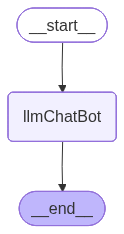

In [11]:
graph

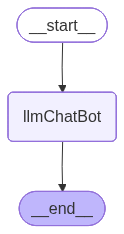

In [12]:
# Another way of showing the graph

from IPython.display import Image, display

try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [14]:
# Running the workflow (invoking)

response = graph.invoke({"messages": "Hi! This is Rick!!!"})

In [15]:
response

{'messages': [HumanMessage(content='Hi! This is Rick!!!', additional_kwargs={}, response_metadata={}, id='89497498-4353-45e6-854d-b07a876ea79e'),
  AIMessage(content="Hi Rick! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 41, 'total_tokens': 67, 'completion_time': 0.029219687, 'completion_tokens_details': None, 'prompt_time': 0.013516188, 'prompt_tokens_details': None, 'queue_time': 0.00749248, 'total_time': 0.042735875}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfa0c-b069-7eb2-b583-9a69719f2b87-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 26, 'total_tokens': 67})]}

In [16]:
response["messages"]

[HumanMessage(content='Hi! This is Rick!!!', additional_kwargs={}, response_metadata={}, id='89497498-4353-45e6-854d-b07a876ea79e'),
 AIMessage(content="Hi Rick! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 41, 'total_tokens': 67, 'completion_time': 0.029219687, 'completion_tokens_details': None, 'prompt_time': 0.013516188, 'prompt_tokens_details': None, 'queue_time': 0.00749248, 'total_time': 0.042735875}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfa0c-b069-7eb2-b583-9a69719f2b87-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 26, 'total_tokens': 67})]

In [19]:
response["messages"][-1]

AIMessage(content="Hi Rick! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 41, 'total_tokens': 67, 'completion_time': 0.029219687, 'completion_tokens_details': None, 'prompt_time': 0.013516188, 'prompt_tokens_details': None, 'queue_time': 0.00749248, 'total_time': 0.042735875}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfa0c-b069-7eb2-b583-9a69719f2b87-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 26, 'total_tokens': 67})

In [20]:
response["messages"][-1].content

"Hi Rick! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [21]:
for event in graph.stream({"messages": "Hi! This is Rick!! How's everything going ?"}):
  print(event)


{'llmChatBot': {'messages': [AIMessage(content="Nice to meet you, Rick! Everything's going well here. I'm a large language model, so I don't have emotions or personal experiences, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 46, 'total_tokens': 111, 'completion_time': 0.082709599, 'completion_tokens_details': None, 'prompt_time': 0.003214559, 'prompt_tokens_details': None, 'queue_time': 0.169412839, 'total_time': 0.085924158}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfa0f-519b-7563-98cc-e2c6904816d7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 65, 'total_tokens': 111})]}}


In [ ]:
for event in graph.stream({"messages": "Hi! This is Rick!! How's everything going ?"}):
  for value in event.values():
    print(value["messages"][-1].content)

Nice to meet you, Rick! I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. What's on your mind today?
